In [56]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [57]:
cifar10 = tf.keras.datasets.cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [58]:
print(x_train.shape)

(50000, 32, 32, 3)


In [59]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer','dog', 'frog', 'house', 'ship', 'truck']

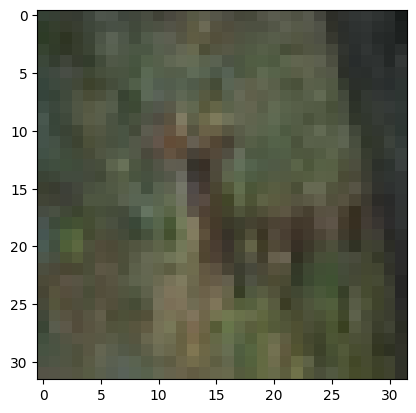

In [60]:
plt.imshow(x_train[10])
plt.show()

In [61]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [62]:
#y_train = y_train.flatten()
#y_test = y_test.flatten()

In [63]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same', input_shape = (32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),

    layers.Dense(512, activation = 'relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation = 'softmax')
])

C:\Users\tanis\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [64]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [65]:
model.fit(x_train, y_train, epochs = 8, validation_data = (x_test, y_test))

Epoch 1/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - accuracy: 0.4884 - loss: 1.4688 - val_accuracy: 0.6324 - val_loss: 1.0170
Epoch 2/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.6589 - loss: 0.9701 - val_accuracy: 0.7196 - val_loss: 0.7957
Epoch 3/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.7103 - loss: 0.8308 - val_accuracy: 0.7252 - val_loss: 0.7883
Epoch 4/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - accuracy: 0.7397 - loss: 0.7443 - val_accuracy: 0.7557 - val_loss: 0.7165
Epoch 5/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.7668 - loss: 0.6798 - val_accuracy: 0.7635 - val_loss: 0.6866
Epoch 6/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.7869 - loss: 0.6199 - val_accuracy: 0.6927 - val_loss: 0.9227
Epoch 7/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.8013 - loss: 0.5795 - val_accuracy: 0.8007 - val_loss: 0.5850
Epoch 8/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.8142 - loss: 0

In [66]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print('Test accuracy :', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8051 - loss: 0.5680
Test accuracy : 0.8051000237464905


In [67]:
predictions = model.predict(x_test)
print(predictions[10])
print('Predicted label :', class_names[np.argmax(predictions[10])])

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
[5.2193183e-01 1.6947660e-04 1.6979214e-02 2.3125039e-01 2.4762478e-02
 1.3254783e-01 1.3924269e-03 1.8713471e-02 5.1959176e-02 2.9376530e-04]
Predicted label : airplane
